In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
import os
import numpy as np
from paths import path
from lib import read_vplanet
from lib import sigfigs
import glob

In [12]:
# Plot atmospheric evolution ranges.
def plot_volatile_loss(run_dir):
    min_mass_loss_inner_HZ = read_vplanet(path(run_dir, 'run_K0_ThU0_a0', 'star.earth.forward'))
    min_mass_loss_outer_HZ = read_vplanet(path(run_dir, 'run_K0_ThU0_a1', 'star.earth.forward'))
    max_mass_loss_inner_HZ = read_vplanet(path(run_dir, 'run_K1_ThU1_a0', 'star.earth.forward'))
    max_mass_loss_outer_HZ = read_vplanet(path(run_dir, 'run_K1_ThU1_a1', 'star.earth.forward'))

    mass_loss_type = run_dir.split("_")[-1] # Either "atm" or "water"

    mass_loss_type_VPLanet = "" 
    
    if mass_loss_type == "water":
        mass_loss_type_VPLanet = "SurfWaterMass"
    elif mass_loss_type == "atm":
        mass_loss_type_VPLanet = "EnvelopeMass"
    else:
        raise Exception("Mass loss type not found!")

    mask = ((min_mass_loss_outer_HZ[mass_loss_type_VPLanet] > 0.0) |
            (min_mass_loss_inner_HZ[mass_loss_type_VPLanet] > 0.0) |
            (max_mass_loss_inner_HZ[mass_loss_type_VPLanet] > 0.0) |
            (max_mass_loss_outer_HZ[mass_loss_type_VPLanet] > 0.0)) & (min_mass_loss_outer_HZ['Time'] < 6e9)
    
    final_index = np.argmin(mask)
    mask[final_index] = True # Include the final zero point.
    
    time_yr = min_mass_loss_outer_HZ['Time'][mask]
    time_scale_yr = 0

    # Checks if the time sequence exceeds 1 Gyr.
    if time_yr.iloc[-1] > 1e9:
        time_scale_yr = 1e9
    else:
        time_scale_yr = 1e6

    if mass_loss_type == "water":
        mass_scale_units = 1 # In T.O.
    elif mass_loss_type == "atm":
        mass_scale_units = 1e20 # In kg.
    else:
        raise Exception("Mass loss type not found!")

    fig, ax = plt.subplots()

    ax.fill_between(time_yr/time_scale_yr, min_mass_loss_outer_HZ[mass_loss_type_VPLanet][mask]/mass_scale_units, max_mass_loss_outer_HZ[mass_loss_type_VPLanet][mask]/mass_scale_units, label = 'Outer HZ', color = '#89023E')
    ax.fill_between(time_yr/time_scale_yr, min_mass_loss_inner_HZ[mass_loss_type_VPLanet][mask]/mass_scale_units, max_mass_loss_inner_HZ[mass_loss_type_VPLanet][mask]/mass_scale_units, label = 'Inner HZ', color = "#F17105")
    ax.fill_between(time_yr/time_scale_yr, max_mass_loss_inner_HZ[mass_loss_type_VPLanet][mask]/mass_scale_units, min_mass_loss_outer_HZ[mass_loss_type_VPLanet][mask]/mass_scale_units, label = 'Inner HZ', color = '#C7D9B7')

    if time_scale_yr == 1e9:
        ax.set_xlabel("Time [Gyr]", fontsize = 12)
    elif time_scale_yr == 1e6:
        ax.set_xlabel("Time [Myr]", fontsize = 12)

    if mass_loss_type == "water":
        ax.set_ylabel(r"Water mass [T.O.]", fontsize = 12)
    elif mass_loss_type == "atm":
        ax.set_ylabel(r"Atmospheric mass [$\times 10^{20}$ kg]", fontsize = 12)

    return fig, ax

synthesis_dir = path('data', 'parameter_sweeps', 'synthesis')

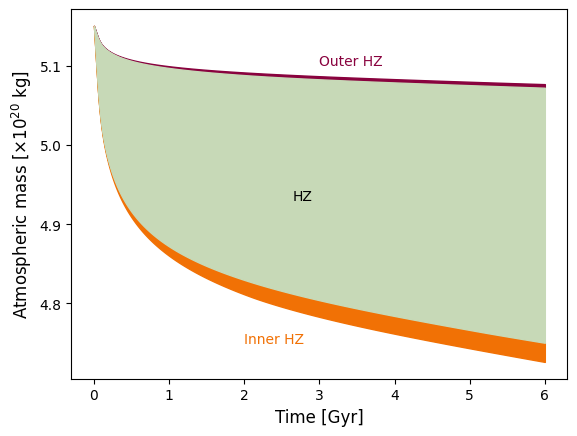

In [13]:
# Sun atmosphere loss.
(fig, ax) = plot_volatile_loss(path(synthesis_dir, 'sun_atm'))
ax.text(3, 5.1, 'Outer HZ', color = '#89023E')
ax.text(2.65, 4.93, 'HZ', color = 'black')
ax.text(2, 4.75, 'Inner HZ', color = '#F17105')
fig.savefig(path("plots", "sun_atm_evolution.png"), bbox_inches = "tight", dpi = 300)

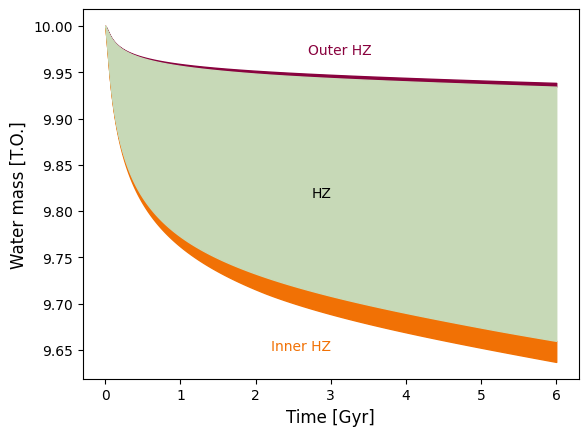

In [14]:
# Sun water loss.
(fig, ax) = plot_volatile_loss(path(synthesis_dir, 'sun_water'))
ax.text(2.7, 9.97, 'Outer HZ', color = '#89023E')
ax.text(2.75, 9.815, 'HZ', color = 'black')
ax.text(2.2, 9.65, 'Inner HZ', color = '#F17105')
fig.savefig(path("plots", "sun_water_evolution.png"), bbox_inches = "tight", dpi = 300)

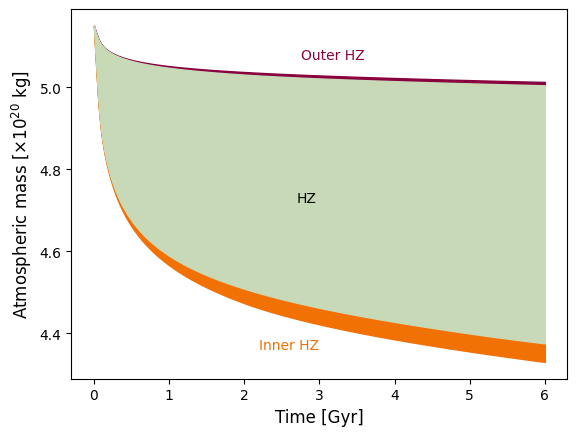

In [58]:
# K-dwarf atmospheric loss.
(fig, ax) = plot_volatile_loss(path(synthesis_dir, 'kv_atm'))
ax.text(2.2, 4.36, 'Inner HZ', color = '#F17105')
ax.text(2.7, 4.72, 'HZ', color = 'black')
ax.text(2.75, 5.07, 'Outer HZ', color = '#89023E')
fig.savefig(path("plots", "kv_atm_evolution.png"), bbox_inches = "tight", dpi = 300)

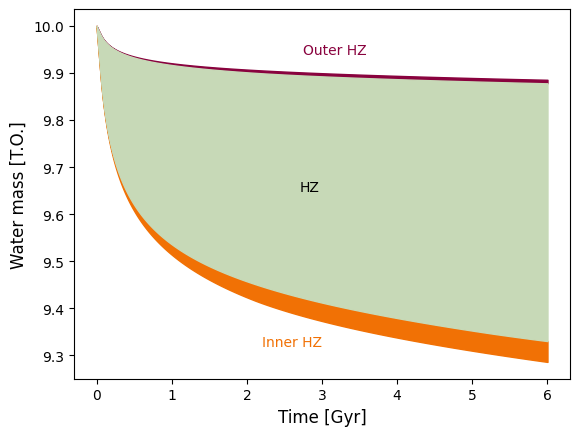

In [50]:
# K-dwarf water loss.
(fig, ax) = plot_volatile_loss(path(synthesis_dir, 'kv_water'))
ax.text(2.2, 9.32, 'Inner HZ', color = '#F17105')
ax.text(2.7, 9.65, 'HZ', color = 'black')
ax.text(2.75, 9.94, 'Outer HZ', color = '#89023E')
fig.savefig(path("plots", "kv_water_evolution.png"), bbox_inches = "tight", dpi = 300)

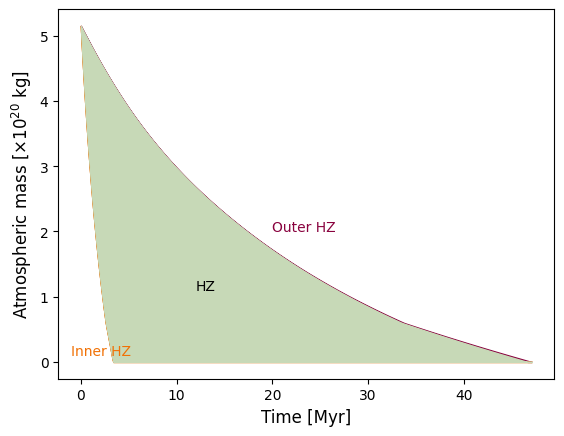

In [43]:
(fig, ax) = plot_volatile_loss(path(synthesis_dir, 'trappist_atm'))
ax.text(20, 2, 'Outer HZ', color = '#89023E')
ax.text(12, 1.1, 'HZ', color = 'black')
ax.text(-1, 0.1, 'Inner HZ', color = '#F17105')
fig.savefig(path("plots", "trappist_atm_evolution.png"), bbox_inches = "tight", dpi = 300)

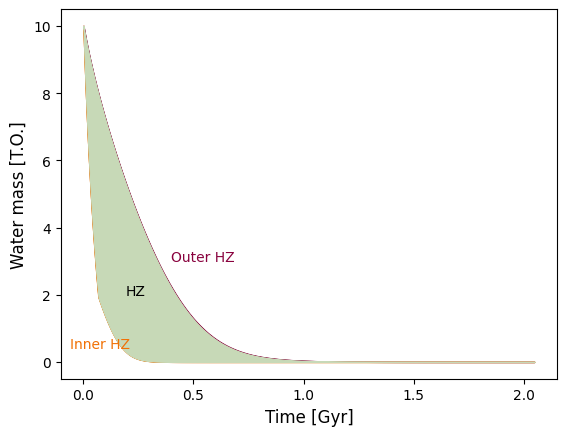

In [30]:
(fig, ax) = plot_volatile_loss(path(synthesis_dir, 'trappist_water'))
ax.text(0.4, 3, 'Outer HZ', color = '#89023E')
ax.text(0.19, 2, 'HZ', color = 'black')
ax.text(-0.06, 0.4, 'Inner HZ', color = '#F17105')
fig.savefig(path("plots", "trappist_water_evolution.png"), bbox_inches = "tight", dpi = 300)

In [25]:
mass_map = {
    'trappist': 0.0899,
    'm0p1': 0.1,
    'm0p2': 0.2,
    'm0p3': 0.3,
    'm0p4': 0.4,
    'm0p5': 0.5,
    'm0p6': 0.6,
    'm0p7': 0.7,
    'm0p8': 0.8,
    'kv': 0.86,
    'm0p9': 0.9,
    'sun': 1,
    'm1p1': 1.1,
    'm1p2': 1.2,
}

# Mode must be "atm" or "water"
def plot_volatile_loss_by_stellar_host(mode):
    if mode != "atm" and mode != "water":
        raise ValueError('Parameter \"mode\" must be either \"atm\" or \"water\"!')

    synthesis_dir = path("data", "parameter_sweeps", "synthesis")

    atm_mass_loss_directories = glob.glob(path(synthesis_dir, "*" + mode))
    NUM_SIMS = len(atm_mass_loss_directories)

    masses = np.zeros(NUM_SIMS) # x-axis data.
    lowest_mass_loss_inner_hz = np.zeros(NUM_SIMS)
    lowest_mass_loss_outer_hz = np.zeros(NUM_SIMS)
    highest_mass_loss_inner_hz = np.zeros(NUM_SIMS)
    highest_mass_loss_outer_hz = np.zeros(NUM_SIMS)

    # Sorts the mass loss directory list by host star mass using the mass map.
    list.sort(atm_mass_loss_directories, key = lambda a: mass_map[a.split(os.sep)[-1].replace("_" + mode, "")])

    for (idx, atm_mass_loss_directory) in enumerate(atm_mass_loss_directories):
        input_files = glob.glob(path(atm_mass_loss_directory, "run_K0_ThU0_a0", "*.in"))

        for input_file in input_files:
            if "vpl.in" not in input_file and "earth.in" not in input_file:
                with open(input_file, "r") as stellar_input_file:
                    contents = stellar_input_file.read()

                    host_mass = float(contents.split("dMass")[1].replace(" ", "").split("\n")[0].split("e")[0])/2

                    masses[idx] = host_mass

        min_mass_loss_inner_hz = read_vplanet(path(atm_mass_loss_directory, 'run_K0_ThU0_a0', 'star.earth.forward'))
        min_mass_loss_outer_hz = read_vplanet(path(atm_mass_loss_directory, 'run_K0_ThU0_a1', 'star.earth.forward'))
        max_mass_loss_inner_hz = read_vplanet(path(atm_mass_loss_directory, 'run_K1_ThU1_a0', 'star.earth.forward'))
        max_mass_loss_outer_hz = read_vplanet(path(atm_mass_loss_directory, 'run_K1_ThU1_a1', 'star.earth.forward'))

        time_yr = 6e9
        mask = min_mass_loss_inner_hz['Time'] == time_yr

        mass_type = {
            "atm": "EnvelopeMass",
            "water": "SurfWaterMass"
        }[mode]

        lowest_mass_loss_inner_hz[idx] = min_mass_loss_inner_hz[mass_type][mask].iloc[0]
        highest_mass_loss_inner_hz[idx] = max_mass_loss_inner_hz[mass_type][mask].iloc[0]
        lowest_mass_loss_outer_hz[idx] = min_mass_loss_outer_hz[mass_type][mask].iloc[0]
        highest_mass_loss_outer_hz[idx] = max_mass_loss_outer_hz[mass_type][mask].iloc[0]

    fig, ax = plt.subplots()

    ax.fill_between(masses, lowest_mass_loss_outer_hz, highest_mass_loss_inner_hz, color = '#C7D9B7')
    ax.fill_between(masses, lowest_mass_loss_outer_hz, highest_mass_loss_outer_hz, color = '#89023E', label = 'Outer HZ')
    ax.fill_between(masses, lowest_mass_loss_inner_hz, highest_mass_loss_inner_hz, color = '#F17105', label = 'Inner HZ')

    ax.set_xlabel("Stellar host mass [solar masses]", fontsize = 12)

    if mode == "atm":
        ax.set_ylabel(r"Atmosphere remaining after 6 Gyr [$\times 10^{20}$ kg]", fontsize = 12)

        ax.set_xlim(-0.05)
        ax.set_ylim(-0.4e20, 5.5e20)

        ax.tick_params(axis = 'both', labelsize = 12)
        ax.yaxis.set_major_locator(tck.FixedLocator([0e20, 1e20, 2e20, 3e20, 4e20, 5e20]))
        ax.yaxis.set_major_formatter(tck.FuncFormatter(lambda x, pos: x/1e20))
        ax.xaxis.set_major_locator(tck.FixedLocator([mass_map['trappist'], mass_map['sun'], mass_map['kv'], 0.3, 0.5, 0.7, 1.2]))
        ax.xaxis.set_major_formatter(tck.FuncFormatter(lambda x, pos: sigfigs(x, 2)))

        (xmin, xmax) = ax.get_xlim()
        ax.hlines(0.0e20, xmin, xmax, color = 'black', zorder = 0, linestyles = 'dashed', alpha = 0.5)

        ax.text(0.35, 3.1e20, 'Outer\nHZ', color = '#89023E')
        ax.text(0.8, 2e20, 'Inner\nHZ', color = '#F17105')
        ax.text(0.6, 2.7e20, 'HZ')
    elif mode == "water":
        ax.set_ylabel("Water remaining after 6 Gyr [T.O.]", fontsize = 12)

        ax.set_xlim(-0.05)
        ax.set_ylim(-0.9)

        ax.xaxis.set_major_locator(tck.FixedLocator([mass_map['trappist'], mass_map['sun'], mass_map['kv'], 0.3, 0.5, 0.7, 1.2]))
        ax.xaxis.set_major_formatter(tck.FuncFormatter(lambda x, pos: sigfigs(x, 2)))
        ax.tick_params(axis = 'both', labelsize = 12)

        ax.text(0.7, 3.9, 'Inner\nHZ', color = '#F17105',)
        ax.text(0.5, 5.3, 'HZ')
        ax.text(0.25, 6, 'Outer\nHZ', color = '#89023E')

        (xmin, xmax) = ax.get_xlim()
        ax.hlines(0.0, xmin, xmax, color = 'black', zorder = 0, linestyles='dashed', alpha = 0.5)

    inset_ax = ax.inset_axes([0, 0, 1, 1], xlim = ax.get_xlim(), ylim = ax.get_ylim(), xticks = [mass_map['trappist'], mass_map['kv'], mass_map['sun']], zorder = -1)
    inset_ax.yaxis.set_visible(False)
    inset_ax.tick_params(axis = 'x', direction = 'in', pad = -14)
    inset_ax.xaxis.set_major_formatter(lambda x, pos: ['TRAPPIST-1', 'KV', 'Sun'][pos])

    return fig, ax

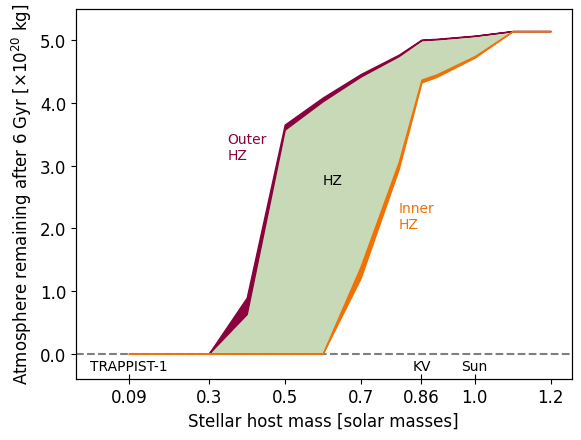

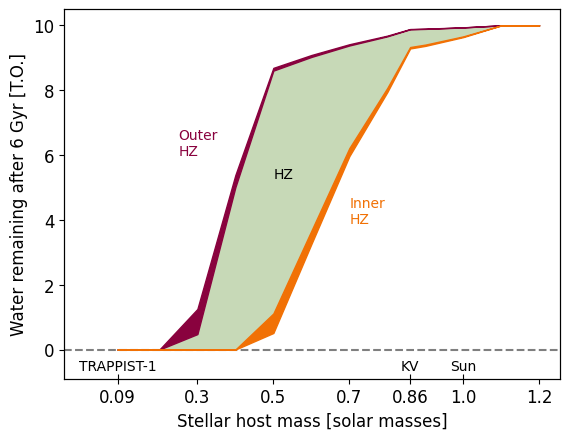

In [26]:
(fig, ax) = plot_volatile_loss_by_stellar_host("atm")
fig.savefig(path("plots", "synthesis_atm.png"), bbox_inches = "tight", dpi = 300)

(fig, ax) = plot_volatile_loss_by_stellar_host("water")
fig.savefig(path("plots", "synthesis_water.png"), bbox_inches = "tight", dpi = 300)